In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

In [2]:
f = h5py.File('/data/user/akatil/electron_neutrino/for_real/PISA/data/upgrade_with_all_var_029_extended.hdf5')

In [3]:
random_varaible = ([])
for k in f.keys():
    random_varaible = np.append(random_varaible,np.array(f[k]['RandomNumber']))

Text(0.5, 0, 'random variable')

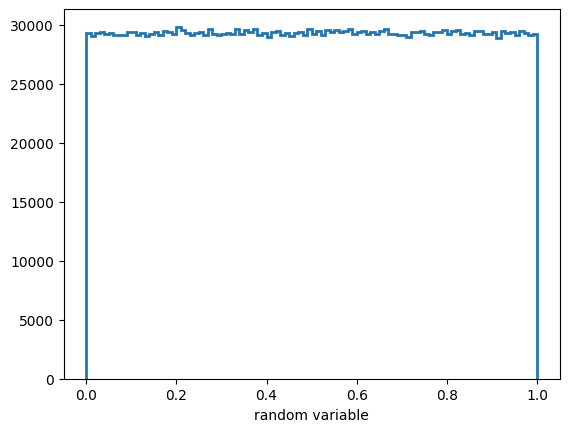

In [14]:
plt.hist(random_varaible, bins=100, histtype='step', lw=2)
plt.xlabel('random variable')

In [1]:
24145//5000

4

In [2]:
73299//15000

4

In [3]:
(313*100 + 10000 - 1 )//10000

4

# Checking NuE Inelasticity

In [11]:
with tables.open_file("/data/user/akatil/electron_neutrino/for_real/PISA/data/upgrade_with_all_var_029_extended.hdf5", mode="r") as file:
    for group_name in group_names:
        group = getattr(file.root, group_name)

        table = None

        for node in group:
            if isinstance(node, tables.Array):
                array = group['I3GenieResult.y']
                data = array.read()
                table = node[data <= 0.1]
                print(table)

        if table is None:
            print(f" No table found in group {group_name}")

        break

[9.17115712e-03 6.32186684e-04 7.94772068e-05 ... 3.49398816e-02
 8.62097359e-03 1.99196678e-04]
[3.41917600e-03 3.39891591e-04 2.61640441e-05 ... 1.34153161e-02
 1.48827096e-03 3.32878485e-05]
[2.35143632e-03 2.23465087e-04 2.55037863e-05 ... 5.78345674e-03
 4.01089417e-03 1.57920271e-04]
[1.97916808e-03 1.51293499e-04 9.21448805e-06 ... 4.64407833e-03
 4.65479266e-03 5.87043477e-04]
[6.71752411e-04 1.51097386e-04 1.12175800e-05 ... 2.74671648e-03
 2.02117347e-03 8.28329221e-04]
[14.5027338  21.46748701 15.09101196 ... 39.25228984 16.35230706
  9.06280065]
[0 1 1 ... 1 0 1]
[1 1 1 ... 1 1 1]
[ 304  369 1446 ... 9211 9381 9596]
[120029 120029 120029 ... 120029 120029 120029]
[1 0 0 ... 0 0 0]
[535 535 535 ... 289 289 289]
[260970 260970 260970 ... 263272 263272 263272]
[120029 120029 120029 ... 120029 120029 120029]
[16 16 16 ... 16 16 16]
[0.04443216 0.38814494 1.09178884 ... 0.29525664 0.09833884 0.08020629]
[1.00966465 0.9356763  1.09165727 ... 1.28900851 0.94274973 1.25559263]
[8 8

In [2]:
import pandas

In [1]:
import tables
import numpy as np
import matplotlib.pyplot as plt
from icecube.phys_services import I3Calculator
import random

In [2]:
group_names = ['nue_cc', 'nuebar_cc',]

In [3]:
inelas_data = 0
with tables.open_file("/data/user/akatil/electron_neutrino/for_real/PISA/data/upgrade_with_all_var_029_inelasticity.hdf5", mode="r") as file:
    for group_name in group_names:
        group = getattr(file.root, group_name)

        updated = False

        #inelasticity = group['I3GenieResult.y']
        #inelasticity_arr = inelasticity.read()

        for node in group:
            if isinstance(node, tables.Array):
                data = node.read()
                #filtered = data[inelasticity_arr <= 0.1]

                print(len(data))#, len(inelasticity_arr))
                inelas_data+=len(data)
                # remove old node and write filtered data back
                node_name = node.name
                print(node_name)
                break

76809
Beta1Reco
63782
Beta1Reco


In [4]:
76809+63782, 292861+175598 

(140591, 468459)

In [5]:
group_names = ['nue_cc', 'nuebar_cc',
    'nue_nc', 'nuebar_nc',
    'numu_cc', 'numu_nc', 'numubar_cc', 'numubar_nc',
    'nutau_cc', 'nutau_nc', 'nutaubar_cc', 'nutaubar_nc'
]

In [6]:
total_data = 0
with tables.open_file("/data/user/akatil/electron_neutrino/for_real/PISA/data/upgrade_with_all_var_029_tilde_inelasticity.hdf5", mode="r") as file:
    for group_name in group_names:
        group = getattr(file.root, group_name)

        updated = False 

        print(group_name)

        for node in group:
            if isinstance(node, tables.Array):
                data = node.read()

                print(len(data))

                total_data+=len(data)

                # remove old node and write filtered data back
                #node_name = node.name
                #print(node_name)
                break

nue_cc
481531
nuebar_cc
165985
nue_nc
77559
nuebar_nc
25724
numu_cc
1042943
numu_nc
148170
numubar_cc
487936
numubar_nc
53954
nutau_cc
107446
nutau_nc
108167
nutaubar_cc
53731
nutaubar_nc
38846


In [7]:
inelas_data/(inelas_data+total_data) + total_data/(inelas_data+total_data)

1.0

In [12]:
np.round(inelas_data/(inelas_data+total_data), 10)

0.0479410131

In [9]:
inelas_data/(total_data)

0.05035508697732658

In [9]:
inelas_data, total_data

(140591, 2791992)